In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [5]:
# Load the Boston Housing dataset
data = pd.read_csv('BostonHousing.csv')     
X = data.drop(columns = ['medv'], axis = 1).values
y = data['medv'].values

In [10]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=2)

In [11]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [16]:
# Train the model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Training Score: ", model.score(X_train_scaled, y_train))
print("Testing Score: ", model.score(X_test_scaled, y_test))

Training Score:  0.8013428862314379
Testing Score:  0.7083250382595931


In [17]:
# Make predictions
y_pred = model.predict(X_test_scaled)


In [18]:
# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


In [19]:
print(f"Mean Squared Error: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")


Mean Squared Error: 26.32
R2 Score: 0.71


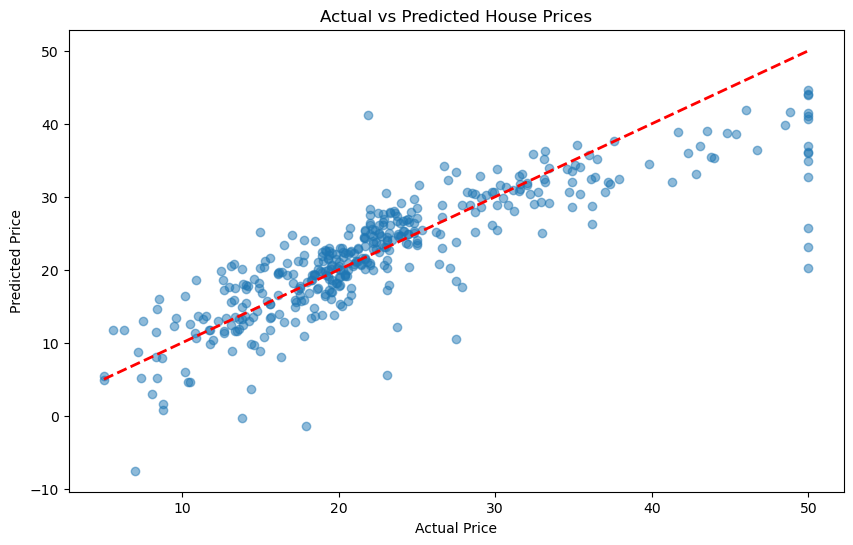

In [21]:
# Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.show()

In [24]:
feature_names = data.drop(columns=['medv']).columns

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": np.abs(model.coef_)
}).sort_values("Importance", ascending=False)


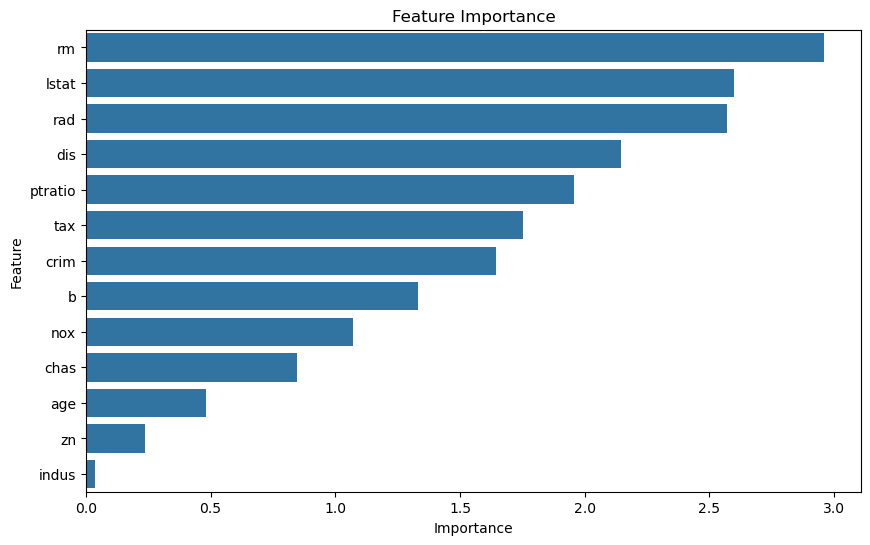

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance')
plt.show() 